Clore, J., Cios, K., DeShazo, J., & Strack, B. (2014). Diabetes 130-US Hospitals for Years 1999-2008 [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5230J.

I downloaded the csv file from the website, which I will use for analysis in the project.

In this project, I will explore how different diabetes medications influence patient outcomes using the Diabetes 130-US Hospitals for Years 1999–2008 dataset. The dataset includes over 100,000 hospital admissions across 130 U.S. hospitals, containing demographic information, diagnostic details, and records of 23 diabetes-related drugs. By analyzing medication patterns, hospital stay length, and readmission rates, this project aims to identify how treatment strategies correlate with clinical outcomes. The analyses include descriptive summaries, visualization of drug usage trends, and predictive modeling of readmission risk based on medication profiles. Through these approaches, the project seeks to uncover meaningful insights into diabetes care quality, treatment intensity, and factors linked to hospital readmission among diabetic patients.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

/Users/tinazhong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### Load and clean dataset

In [2]:
# load the csv file
df = pd.read_csv('diabetic_data.csv')

In [3]:
# Simple ideas of the df
print(df.shape)
pd.set_option('display.max_columns', None)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
# Handle missing values "?" --> NaN
df = df.replace("?", pd.NA)
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),<NA>,6,25,1,1,<NA>,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,<NA>,<NA>,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),<NA>,1,1,7,3,<NA>,<NA>,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),<NA>,1,1,7,2,<NA>,<NA>,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),<NA>,1,1,7,2,<NA>,<NA>,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),<NA>,1,1,7,1,<NA>,<NA>,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
# Examine missingness
missing_counts = df.isna().sum()
missing_rate = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_rate (%)": missing_rate.round(2)
}).sort_values("missing_rate (%)", ascending=False)

missing_df

,missing_count,missing_rate (%)
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
encounter_id,0,0.00


In [7]:
# Drop columns based on missingness, low predictive value, identifiers, and diag_1, diag_2, diag_3 (raw ICD codes)
cols_to_drop = [
    'weight', 
    'max_glu_serum',
    'A1Cresult', 
    'medical_specialty',
    'payer_code',
    'encounter_id',
    'diag_1',
    'diag_2',
    'diag_3'
]

df = df.drop(columns=cols_to_drop)
df.shape

(101766, 41)

In [8]:
# Clean age to numeric value
def age_to_midpoint(age_str):
    # Remove [, ], (, )
    cleaned = age_str.replace("[", "").replace("]", "").replace(")", "")
    low, high = cleaned.split("-")
    return (int(low) + int(high)) / 2

df['age'] = df['age'].apply(age_to_midpoint)

In [9]:
df['age']

0          5.0
1         15.0
2         25.0
3         35.0
4         45.0
          ... 
101761    75.0
101762    85.0
101763    75.0
101764    85.0
101765    75.0
Name: age, Length: 101766, dtype: float64

In [10]:
# Treat race missing as "Unknown"
df['race'] = df['race'].fillna("Unknown")

In [11]:
df['race'].head(10)

0          Caucasian
1          Caucasian
2    AfricanAmerican
3          Caucasian
4          Caucasian
5          Caucasian
6          Caucasian
7          Caucasian
8          Caucasian
9          Caucasian
Name: race, dtype: object

In [12]:
# Inspect race values
df['race'].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [13]:
# Inspect gender values
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [14]:
# Set the "Unknown/Invalid" value to "Unknown"
df['gender'] = df['gender'].replace("Unknown/Invalid", "Unknown")

In [15]:
df['gender'].value_counts()

gender
Female     54708
Male       47055
Unknown        3
Name: count, dtype: int64

In [16]:
# Extract columns of drugs
drug_cols = [
    "metformin","repaglinide","nateglinide","chlorpropamide",
    "glimepiride","acetohexamide","glipizide","glyburide",
    "tolbutamide","pioglitazone","rosiglitazone","acarbose",
    "miglitol","troglitazone","tolazamide","examide",
    "citoglipton","insulin","glyburide-metformin",
    "glipizide-metformin","glimepiride-pioglitazone",
    "metformin-rosiglitazone","metformin-pioglitazone"
]

for col in drug_cols:
    df[col + "_used"] = df[col].apply(lambda x: 0 if x == "No" else 1)

# Drop the original columns
df = df.drop(columns=drug_cols)


In [17]:
# Handle non-numerical columns
# Change: whether change medication or not
df['change'] = df['change'].map({'Ch': 1, 'No': 0})

# Usage of diabetes medication --> 1, else -->0
df['diabetesMed'] = df['diabetesMed'].map({'Yes': 1, 'No': 0})

# Mark 1 for petients readmitted within 30 days, else --> 0
df['readmit_30'] = df['readmitted'].apply(lambda x: 1 if x == "<30" else 0)
df = df.drop(columns=['readmitted'])

In [18]:
# Remove death cases (prevents target leakage)
death_codes = [11, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(death_codes)]

# Define categorical columns for one-hot encoding
cat_cols = [
    'race',
    'gender',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id'
]

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [19]:
df_encoded.head()
df_encoded.shape

(100114, 88)

In [20]:
pd.set_option('display.max_columns', None)
df_encoded.head()

,patient_nbr,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,change,diabetesMed,metformin_used,repaglinide_used,nateglinide_used,chlorpropamide_used,glimepiride_used,acetohexamide_used,glipizide_used,glyburide_used,tolbutamide_used,pioglitazone_used,rosiglitazone_used,acarbose_used,miglitol_used,troglitazone_used,tolazamide_used,examide_used,citoglipton_used,insulin_used,glyburide-metformin_used,glipizide-metformin_used,glimepiride-pioglitazone_used,metformin-rosiglitazone_used,metformin-pioglitazone_used,readmit_30,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown,admission_type_id_2,admission_type_id_3,admission_type_id_4,admission_type_id_5,admission_type_id_6,admission_type_id_7,admission_type_id_8,discharge_disposition_id_2,discharge_disposition_id_3,discharge_disposition_id_4,discharge_disposition_id_5,discharge_disposition_id_6,discharge_disposition_id_7,discharge_disposition_id_8,discharge_disposition_id_9,discharge_disposition_id_10,discharge_disposition_id_12,discharge_disposition_id_13,discharge_disposition_id_14,discharge_disposition_id_15,discharge_disposition_id_16,discharge_disposition_id_17,discharge_disposition_id_18,discharge_disposition_id_22,discharge_disposition_id_23,discharge_disposition_id_24,discharge_disposition_id_25,discharge_disposition_id_27,discharge_disposition_id_28,admission_source_id_2,admission_source_id_3,admission_source_id_4,admission_source_id_5,admission_source_id_6,admission_source_id_7,admission_source_id_8,admission_source_id_9,admission_source_id_10,admission_source_id_11,admission_source_id_13,admission_source_id_14,admission_source_id_17,admission_source_id_20,admission_source_id_22,admission_source_id_25
0,8222157,5.0,1,41,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,55629189,15.0,3,59,0,18,0,0,0,9,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,86047875,25.0,2,11,5,13,2,0,1,6,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,82442376,35.0,2,44,1,16,0,0,0,7,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,42519267,45.0,1,51,0,8,0,0,0,5,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [21]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100114 entries, 0 to 101765
Data columns (total 88 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   patient_nbr                    100114 non-null  int64  
 1   age                            100114 non-null  float64
 2   time_in_hospital               100114 non-null  int64  
 3   num_lab_procedures             100114 non-null  int64  
 4   num_procedures                 100114 non-null  int64  
 5   num_medications                100114 non-null  int64  
 6   number_outpatient              100114 non-null  int64  
 7   number_emergency               100114 non-null  int64  
 8   number_inpatient               100114 non-null  int64  
 9   number_diagnoses               100114 non-null  int64  
 10  change                         100114 non-null  int64  
 11  diabetesMed                    100114 non-null  int64  
 12  metformin_used                 1001

In [22]:
# export the cleaned df
df_encoded.to_csv("clean_diabetes.csv", index=False)

### Data cleaning applied:
First, missing values in the UCI Diabetes dataset are denoted by the character "?", which were replaced with standard NaN values using df.replace("?", np.nan). This allows Python and pandas to recognize them as missing entries. The categorical column readmitted contains three text categories ("NO", "<30", and ">30"), so a new binary target variable readmit_30 was created to flag whether a patient was readmitted within 30 days (1 for "<30", 0 otherwise). Medication-related columns contain text entries like "No", "Steady", "Up", or "Down", which were converted into binary indicators (1 if any drug was used, 0 if not). Additionally, key numerical features such as time_in_hospital, num_medications, and lab or inpatient counts were coerced into numeric format to handle potential text-based inconsistencies. The fields change and diabetesMed were also transformed into binary variables. After these transformations, missing values were standardized, categorical values were encoded, and the dataset was ready for statistical analysis and visualization.

###  EDA

In [23]:
# Quick glance on clean data statistics
df_encoded.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_nbr,100114.0,5.430611e+07,3.871493e+07,135.0,23398668.0,45480775.5,87558363.0,189502619.0
age,100114.0,6.583095e+01,1.594742e+01,5.0,55.0,65.0,75.0,95.0
time_in_hospital,100114.0,4.389646e+00,2.974531e+00,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,100114.0,4.294330e+01,1.962094e+01,1.0,31.0,44.0,57.0,132.0
num_procedures,100114.0,1.330723e+00,1.700286e+00,0.0,0.0,1.0,2.0,6.0
num_medications,100114.0,1.598182e+01,8.092511e+00,1.0,10.0,15.0,20.0,81.0
number_outpatient,100114.0,3.694289e-01,1.264006e+00,0.0,0.0,0.0,0.0,42.0
number_emergency,100114.0,1.983339e-01,9.355372e-01,0.0,0.0,0.0,0.0,76.0
number_inpatient,100114.0,6.328286e-01,1.261833e+00,0.0,0.0,0.0,1.0,21.0
number_diagnoses,100114.0,7.409164e+00,1.938288e+00,1.0,6.0,8.0,9.0,16.0


In [24]:
# Class Imbalance Check for Target
df_encoded['readmit_30'].value_counts(normalize=True)

readmit_30
0    0.886559
1    0.113441
Name: proportion, dtype: float64

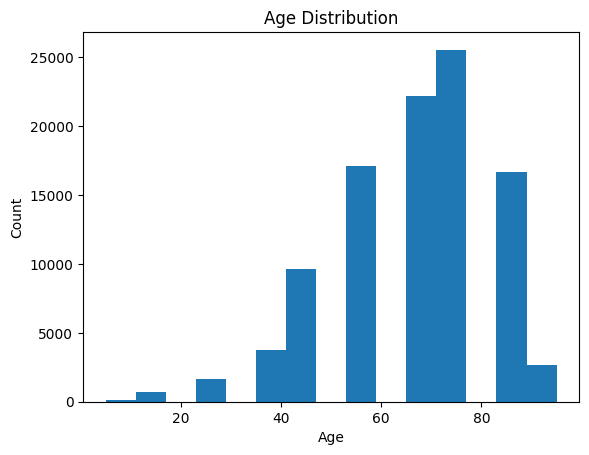

In [25]:
# Age histogram
plt.hist(df_encoded['age'], bins=15)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()


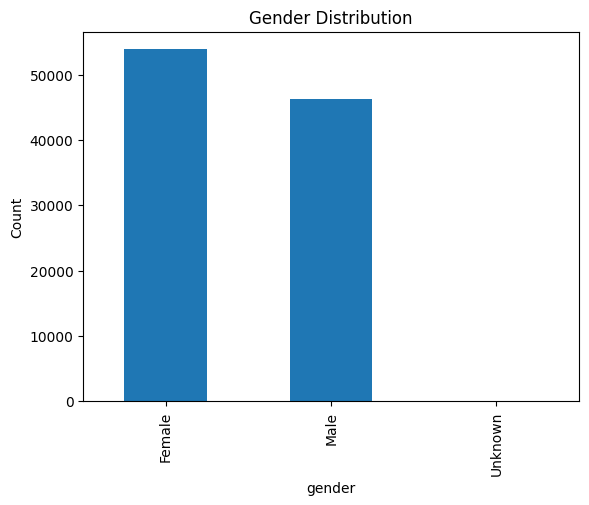

In [26]:
# Gender distribution
df['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.show()

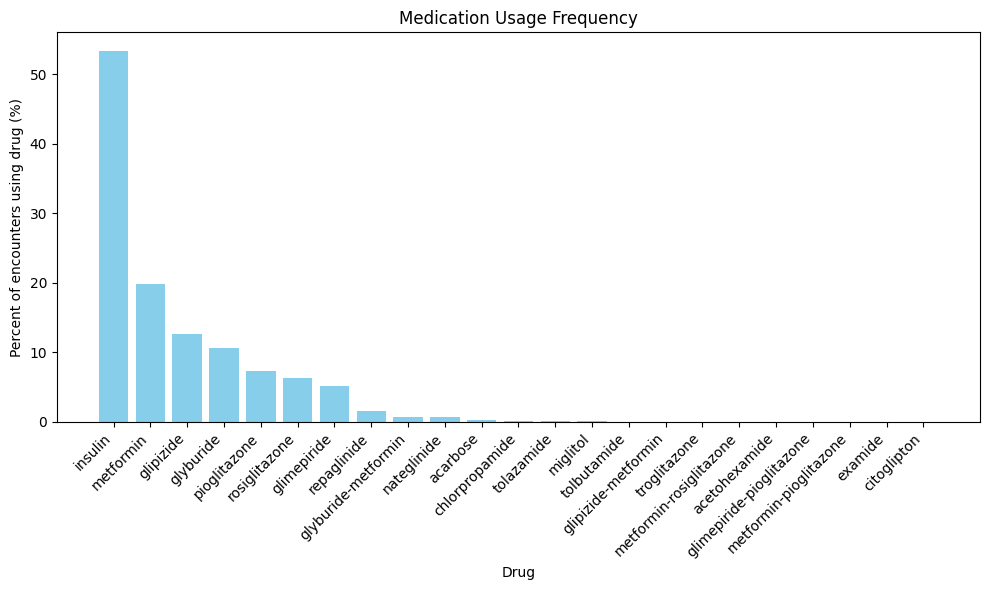

In [27]:
# Medication usage frequency after binary encoding
usage = []

for drug in drug_cols:
    used_col = f"{drug}_used"
    pct_used = df[used_col].mean() * 100
    usage.append((drug, pct_used))

usage_df = (
    pd.DataFrame(usage, columns=["Drug", "PercentUsed"])
    .sort_values("PercentUsed", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(usage_df["Drug"], usage_df["PercentUsed"], color="skyblue")
plt.title("Medication Usage Frequency")
plt.xlabel("Drug")
plt.ylabel("Percent of encounters using drug (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This figure illustrates how frequently each diabetes medication was prescribed in the dataset.Insulin was used in approximately 53% of all admissions, making it the most common treatment. Metformin followed at around 19%, while Glipizide and Glyburide appeared in roughly 12% and 10% of encounters, respectively. These results indicate that real-world diabetes management during 1999–2008 was dominated by insulin and metformin, which were the standard first-line and escalation therapies. The rapid drop in usage frequency across other drugs suggests that treatment practices were concentrated around a few key medications, while alternative agents played a minor or specialized role. The near-zero use of certain drugs likely reflects market withdrawals (e.g., troglitazone) or limited clinical adoption of experimental compounds.

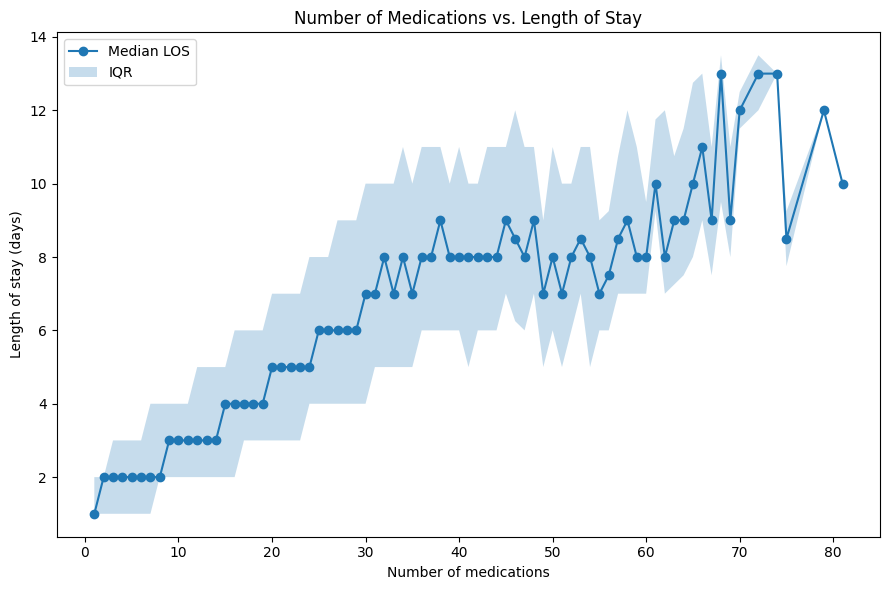

In [28]:
# Number of Medications vs. Length of Stay
# Drop rows missing either field
df = df.dropna(subset=["num_medications", "time_in_hospital"])

# Aggregate: median LOS and IQR per medication count
agg = (
    df.groupby("num_medications")["time_in_hospital"]
      .agg(los_median="median",
           los_q1=lambda s: s.quantile(0.25),
           los_q3=lambda s: s.quantile(0.75))
      .reset_index()
      .sort_values("num_medications")
)

# Plot median line + IQR ribbon
plt.figure(figsize=(9,6))
plt.plot(agg["num_medications"], agg["los_median"], marker="o", label="Median LOS")
plt.fill_between(agg["num_medications"], agg["los_q1"], agg["los_q3"], alpha=0.25, label="IQR")

plt.title("Number of Medications vs. Length of Stay")
plt.xlabel("Number of medications")
plt.ylabel("Length of stay (days)")
plt.legend()
plt.tight_layout()
plt.show()

This figure shows how the length of hospital stay changes with the number of medications prescribed. The trend reveals that patients receiving more medications tend to have longer hospitalizations. The median stay increases from roughly 2 days for patients on fewer than 5 medications to around 8–10 days for those on 30 or more medications, with the interquartile range (IQR) also widening as medication count grows. This positive relationship suggests that number of drug usage is a strong indicator of disease complexity or comorbidity. Patients requiring numerous medications often have more severe conditions, which likely leads to extended hospitalization for monitoring and stabilization. The increasing variability at higher medication counts also implies that treatment complexity contributes to a wider range of clinical outcomes.

In [ ]:
# Readmission rate among users of the five most common drugs
top_drugs = [
    drug for drug, _ in
    sorted(usage, key=lambda item: item[1], reverse=True)[:5]
]

readmit_rates = []
for drug in top_drugs:
    users = df[df[f"{drug}_used"] == 1]
    rate = users["readmit_30"].mean() * 100
    readmit_rates.append((drug, rate))

rate_df = (
    pd.DataFrame(readmit_rates, columns=["Drug", "ReadmissionRate"])
    .sort_values("ReadmissionRate", ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(rate_df["Drug"], rate_df["ReadmissionRate"], color="pink")
plt.title("30-Day Readmission Rate by Medication")
plt.ylabel("Readmission rate (%)")
plt.xlabel("Drug")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

This figure compares 30-day readmission rates among patients prescribed the five most common diabetes medications. Insulin users show the highest readmission rate at about 12%, followed by Glipizide, Glyburide, and Pioglitazone (around 10–11%), while Metformin users have the lowest rate at roughly 9–10%. Because insulin is prescribed much more frequently and often to patients with more severe or advanced diabetes, its higher readmission rate is expected. These patients typically have greater clinical complexity and comorbidities, which contribute to readmissions independent of the medication itself. In contrast, metformin is usually used for milder, better-controlled cases, which explains its association with lower readmission rates. Overall, the trend reflects differences in patient severity and treatment stage rather than the direct effects of the drugs.

In [29]:
from pathlib import Path

print("CSV path:", Path("clean_diabetes.csv").resolve())
print("CSV exists:", Path("clean_diabetes.csv").exists())
print("Rows and columns:", df_encoded.shape)
print("Patient ID retained:", "patient_nbr" in df_encoded.columns)

CSV path: /Users/tinazhong/Desktop/diabetes-readmission-github/clean_diabetes.csv
CSV exists: True
Rows and columns: (100114, 88)
Patient ID retained: True
